In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

#Two new packages!
import xarray as xr
import cartopy.crs as ccrs

In [2]:
#netcdf data
ds = xr.open_dataset('GEOS-CF_AirQuality_20180101_0030z.nc4')

In [3]:
ds

<xarray.Dataset> Size: 21MB
Dimensions:        (time: 1, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time           (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev            (lev) float64 8B 72.0
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float32 4MB ...
    NO2            (time, lev, lat, lon) float32 4MB ...
    O3             (time, lev, lat, lon) float32 4MB ...
    PM25_RH35_GCC  (time, lev, lat, lon) float32 4MB ...
    SO2            (time, lev, lat, lon) float32 4MB ...
Attributes: (12/28)
    Contact:               http://gmao.gsfc.nasa.gov
    History:               Original file generated: Mon Dec 24 13:37:28 2018 GMT
    Source:                cak_Icarus-1_0_GCCv12-00-01_v1_010 experiment_id: ...
    Conventions:           CF-1
    Title:                 GEOS CF (Composition Forecast)
    Institution:           NASA Global Modeling and Assimilation Office
    ...                    ...
    DataResolution:        0.25 x 0.25
    LongName:              GEOS CF 2d time-averaged air quality concentration...
    ShortName:             CF01Raqc_1hrT_g1440x721_V1
    Comment:               GMAO filename: c360_GEOS-CF.chm_tavg_1hr_g1440x721...
    Filename:              GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...
    GranuleID:             GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...

In [4]:
CO = ds.CO

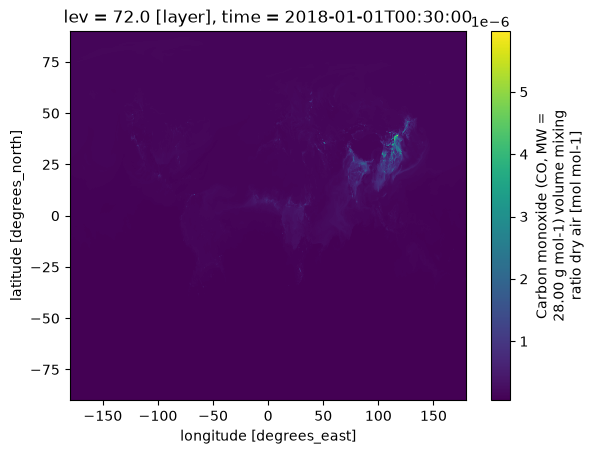

In [5]:
CO.plot() #nice start but lets make some modifications

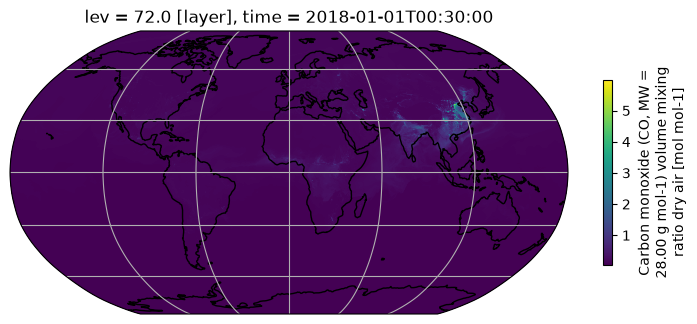

In [6]:
#Elementwise vs matrix operations
CO = ds.CO * 1e6 # convert to ppm

#Plotting basics
#coordinate reference system (map projection)
fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
CO.plot(ax=ax, transform=ccrs.PlateCarree(), 
        cbar_kwargs={'shrink': 0.4}) # This line just makes the axis smaller
ax.coastlines()
ax.gridlines()

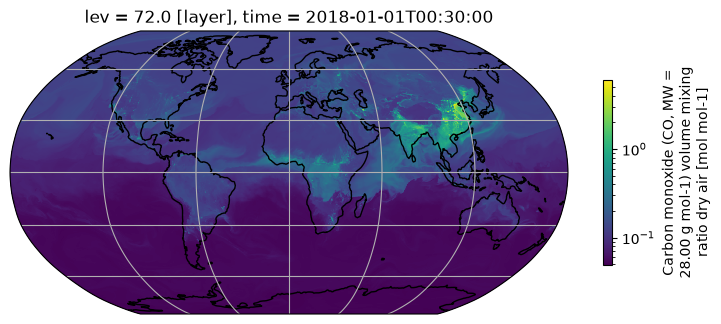

In [7]:
# Let's get log axes!

CO = ds.CO*1e6

fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
CO.plot(ax=ax, transform=ccrs.PlateCarree(),
        norm=colors.LogNorm(), # Normalize the colorbar in log scale
        cbar_kwargs={'shrink': 0.4},)
ax.coastlines()
ax.gridlines()

In [8]:
# Select a specific location
# Tucson lat/lon is 32.2540° N, 110.9742° W

CO.sel(lat=[32.2540], lon=[-110.9742], method="nearest")

<xarray.DataArray 'CO' (time: 1, lev: 1, lat: 1, lon: 1)> Size: 4B
array([[[[0.17340425]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 8B 32.25
  * lon      (lon) float64 8B -111.0
Attributes:
    long_name:       Carbon monoxide (CO, MW = 28.00 g mol-1) volume mixing r...
    units:           mol mol-1
    fmissing_value:  1e+15
    standard_name:   Carbon monoxide (CO, MW = 28.00 g mol-1) volume mixing r...
    vmin:            -1e+15
    vmax:            1e+15
    valid_range:     [-1.e+15  1.e+15]

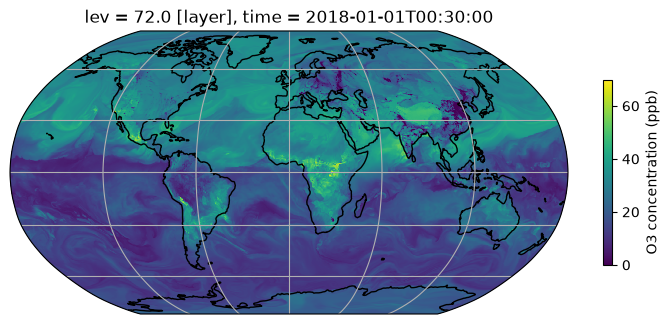

In [9]:
o3 = ds.O3 * 1e9

fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
o3.plot(ax=ax, transform=ccrs.PlateCarree(),
        cbar_kwargs={'shrink': 0.4, 'label': 'O3 concentration (ppb)'})
ax.coastlines()
ax.gridlines()

In [10]:
highest = o3.isel(o3.argmax(dim=["lat", "lon"]))
lowest = o3.isel(o3.argmin(dim=["lat", "lon"]))
la = o3.sel(lat=[34.05], lon=[-118.24], method="nearest")
hawaii = o3.sel(lat=[19.74], lon=[-155.84], method="nearest")

print("Highest:")
print("Latitude:", highest.lat.item(), "Longitude:", highest.lon.item())

print("Lowest:")
print("Latitude:", lowest.lat.item(), "Longitude:", lowest.lon.item())

print("LA:")
print(la.item(), "ppb")

print("Hawaii")
print(hawaii.item(), "ppb")

# a. O3 is relatively high in central Africa and Mexico.
# b. Latitude: 34.5 Longitude: -118.75
# c. O3 is generally lower over the oceans
# d. Latitude: 53.0 Longitude: 73.25
# e. LA: about 45.402 ppb
# f. Hawaii: about 37.253 ppb

Highest:
Latitude: 34.5 Longitude: -118.75
Lowest:
Latitude: 53.0 Longitude: 73.25
LA:
45.401973724365234 ppb
Hawaii
37.25290298461914 ppb
